In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib
import pandas as pd
import seaborn as sns
from scipy.special import softmax

import utilities as utils

### Script parameters and variables

In [ ]:
### operational parameters ###

savedir = "./Figures/"
saveflag = False

beads_datadir = "./Data/beads/"
horses_datadir = "./Data/horses/"

# number of threads for parallelized analyses
N_threads = 22


### parameters governing analyses ###

# confidence interval of I(R;Y) for bootstrapping analyses
CI = (2.5, 97.5)
boot_iters = 1000 # number of bootstrap iterations

# number of beads to include in X, from current trial backward (bead-prediction experiment) for "fully-optimal" strategy
wsize = 7

# limit for the number of iterations for the IB algorithm
IB_iterlimit = 100000


### fixed parameters for the generative structure of the experiments ###

# generative parameters for the bead-prediction experiment
h_=0.99 # jar stay probability
p0_=0.8 # probability of drawing bead type 0 from jar 0
p1_=0.2 # probability of drawing bead type 0 from jar 1
P0 = np.array([[0.5],[0.5]]) # prior over jars for computing posterior probabilities over hidden markov process
H = np.ones((2,2)) - np.abs(np.eye(2)*-1 + h_) # transition matrix
E = np.vstack((np.array([[1,0]])*p0_ + np.array([[0,1]])*(1-p0_),np.array([[1,0]])*p1_ + np.array([[0,1]])*(1-p1_))) # emission matrix

# generative parameters for the horse prediction experiments
paramdict = {
    'lowWS': {
        'weakLLR': 0.45,
        'WSratio': 1.3,
        'p1': 0.06
    },
    'midWS': {
        'weakLLR': 0.2,
        'WSratio': 2.5,
        'p1': 0.08
    },
    'highWS': {
        'weakLLR': 0.18,
        'WSratio': 6.3,
        'p1': 0.02
    }
}

# p(Y) for both tasks
p_Y = np.array([[0.5, 0.5]])


### helper functions ###

def savefig(fig, name, ftype="svg", saveflag=saveflag, savedir=savedir):
    if saveflag:
        fig.savefig(savedir + name + "." + ftype, bbox_inches="tight", dpi=300)

def format_axis(ax):
    ax.tick_params(axis='x', labelsize=5, width=0.5, length=2)
    ax.tick_params(axis='y', labelsize=5, width=0.5, length=2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)

### Import some preprocessed data

In [3]:
# bead prediction trial sequence
beads_trial_seq = pd.read_csv(beads_datadir + "trial_sequence.csv")
jars_emp = beads_trial_seq['jar'].to_numpy()
beads_emp = beads_trial_seq['bead'].to_numpy()

# horse prediction experiment trial sets (emp = empirical data)
lowWS_trial_set = pd.read_csv(horses_datadir + "lowWS/trial_set.csv")
shapes_low_emp = utils.split_to_four_digits(lowWS_trial_set['observation_encoding'].to_numpy())
horses_low_emp = lowWS_trial_set['latent_state'].to_numpy() - 1

midWS_trial_set = pd.read_csv(horses_datadir + "midWS_learning/trial_set.csv")
shapes_mid_emp = utils.split_to_four_digits(midWS_trial_set['observation_encoding'].to_numpy())
horses_mid_emp = midWS_trial_set['latent_state'].to_numpy() - 1

highWS_trial_set = pd.read_csv(horses_datadir + "highWS/trial_set.csv")
shapes_high_emp = utils.split_to_four_digits(highWS_trial_set['observation_encoding'].to_numpy())
horses_high_emp = highWS_trial_set['latent_state'].to_numpy() - 1

## Figure 1
Visual assets for task overviews

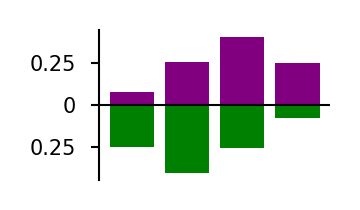

In [23]:
weakLLR = paramdict['midWS']['weakLLR']
WSratio = paramdict['midWS']['WSratio']
pdist1, pdist2 = utils.llr2probs_4shapes(llr=np.array([-weakLLR*WSratio, -weakLLR, weakLLR, weakLLR*WSratio]), p1=paramdict['midWS']['p1'])

fig, ax = plt.subplots(figsize=(1.3,0.8), dpi=300)

ax.bar(np.arange(4), pdist1, color='purple', label='state 1')

ax.bar(np.arange(4), -pdist2, color='green', label='state 2')
xlims = ax.get_xlim()
ax.plot(xlims, [0,0], color='black', linewidth=0.5)
ax.set_xlim(xlims)
ax.axes.get_xaxis().set_visible(False)
ax.set_yticks([-0.25, 0, 0.25])
ax.set_yticklabels(['0.25','0','0.25'])

format_axis(ax)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
savefig(fig, 'Figure1/figure1_likelihoods')
# plt.savefig(savedir+'Figure1/figure1_likelihoods.svg', bbox_inches='tight')

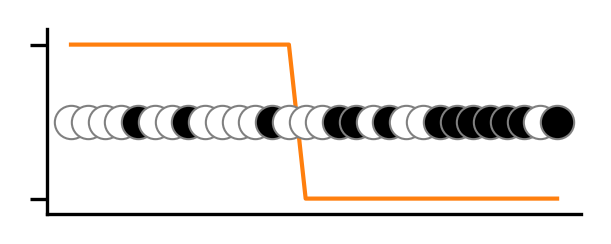

In [5]:
mfcs = {
    0: 'black',
    1: 'white'
}

mecs = {
    1: 'gray',
    0: 'gray'
}

cmap = plt.get_cmap("tab10")

fig = plt.figure(figsize=(2.3,0.8), dpi=300)
ax = fig.add_subplot(111)

ax.plot(jars_emp[55:85],c=cmap(1),linewidth=1)
for tt in range(55,85):
    ax.plot(tt-55,0.5,'o',markersize=8,markeredgewidth=0.5,mec=mecs[beads_emp[tt]],mfc=mfcs[beads_emp[tt]])
ax.set_ylim([-0.1,1.1])
ax.set_xticks([])
ax.set_yticks([0,1],labels=[])

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.8)

ax.tick_params(axis='x', labelsize=5, width=0.8, length=4)
ax.tick_params(axis='y', labelsize=5, width=0.8, length=4)
sns.despine()
# ax.spines['bottom'].set_linewidth(0.5)
# ax.spines['left'].set_linewidth(0.5)
savefig(fig, 'Figure1/figure1_bead_seq')

## Figure 2
Basic IB theoretical results and visual assets for the figure

In [ ]:
# get IB bound (IB-optimal for true p(X,Y)) on the experimental trial set
shapes_Xset = utils.get_shapes_Xset()
p_XgY = utils.P_shapecomb_g_horse(shapes_Xset,paramdict['highWS']['weakLLR'],paramdict['highWS']['WSratio'],paramdict['highWS']['p1'])
emp_bound = utils.get_IB_bound_emp(shapes_high_emp,shapes_Xset,horses_high_emp,p_XgY,p_Y,iterlimit=IB_iterlimit,N_threads=N_threads)

# get IB curve for softmax solution on the experimental trial set
p_YgX_emp = utils.P_horse_g_shapecomb(shapes_high_emp,paramdict['highWS']['weakLLR'],paramdict['highWS']['WSratio'],paramdict['highWS']['p1'],p_Y=p_Y)
emp_softmax_curve = utils.get_softmax_IB_curve_emp(shapes_high_emp,horses_high_emp,p_YgX_emp)

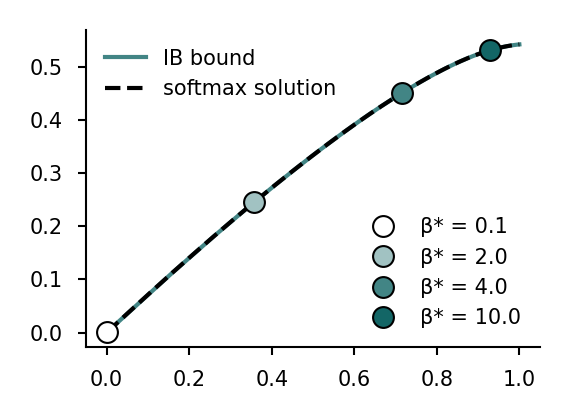

In [29]:
import matplotlib.colors as mcolors

start_color = "#ffffff"  
end_color = "#136666"    

def get_color(index,values,vmin,vmax):
    return np.clip(1-(values[index]-vmin)/(vmax-vmin),0,1)

cmap_t = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [start_color, end_color])

betastars = np.array([0.1, 2, 4, 10])

fig, ax = plt.subplots(figsize=(2,1.5), dpi=300)

ibbound, = ax.plot(emp_bound['I_XR'], emp_bound['I_RY'], label='IB bound', color=cmap_t(0.8), linewidth=1)
softmaxbound, = ax.plot(emp_softmax_curve['I_XR'], emp_softmax_curve['I_RY'], '--k',linewidth=1, label='softmax solution')

legend_handles = []
legend_labels = []
for ii, bb in enumerate(betastars):
    softmax_soln = utils.get_softmax_IB_emp(bb,shapes_high_emp,horses_high_emp,p_YgX_emp,return_dict=True)
    if ii == 0:
        soln, = ax.plot(softmax_soln['I_XR'], softmax_soln['I_RY'],'o',c=cmap_t(1-get_color(ii,betastars,1,5)),markeredgecolor='k',markersize=5,markeredgewidth=0.5)
    else:
        soln, = ax.plot(softmax_soln['I_XR'], softmax_soln['I_RY'],'o',c=cmap_t(1-get_color(ii,betastars,0,5)),markeredgecolor='k',markersize=5,markeredgewidth=0.5)
    legend_handles.append(soln,)
    legend_labels.append(f'β* = {bb}')
format_axis(ax)
leg1 = ax.legend(legend_handles, legend_labels, fontsize=5, frameon=False, loc='lower right')
leg2 = ax.legend([ibbound, softmaxbound], ['IB bound', 'softmax solution'], fontsize=5, frameon=False, loc='upper left')
ax.add_artist(leg1)
plt.tight_layout()
savefig(fig, 'Figure2/figure2_IBbound')

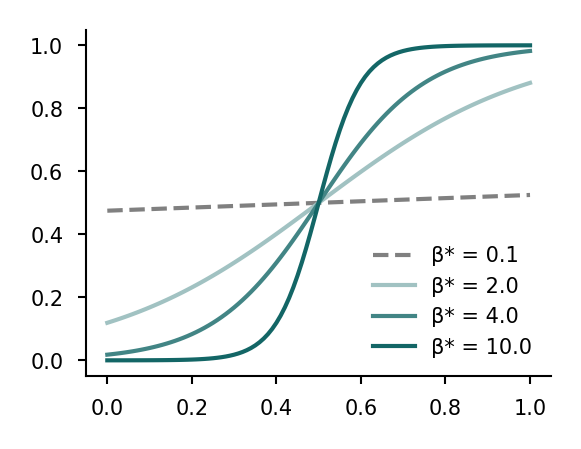

In [30]:
p = np.arange(0,1.01,0.01).reshape(-1,1)

legend_handles = []  
legend_labels = []

fig, ax = plt.subplots(figsize=(2,1.5), dpi=300)

for ii, bb in enumerate(betastars):
    curve = softmax(bb*np.concatenate((p,1-p),axis=1),axis=1)
    if ii == 0:
        line, = ax.plot(p, curve[:, 0],'--', c='gray', label=f'β* = {bb}',linewidth=1)
    else:
        line, = ax.plot(p,curve[:,0],c=cmap_t(1-get_color(ii,betastars,0,5)), label=f'β = {bb}',linewidth=1)
    legend_handles.append(line)
    legend_labels.append(f'β* = {bb}')
format_axis(ax)
ax.legend(legend_handles, legend_labels, fontsize=5, frameon=False, loc='lower right')
savefig(fig, 'Figure2/figure2_softmax_PFs')

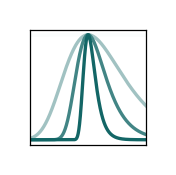

In [31]:
from scipy.stats import gumbel_r

fig, ax = plt.subplots(figsize=(0.5,0.5), dpi=300)

x = np.arange(-100,100,0.01)
p1 = 0.3
p2 = 0.7

for ii, bb in enumerate(betastars):
    iline2, = ax.plot(x/bb+p2,gumbel_r.pdf(x),c=cmap_t(1-get_color(ii,betastars,0,5)),linewidth=0.8)

ax.set_xlim([p2-1,p2+1])
ylim = ax.get_ylim()
ax.set_ylim(ylim)
ax.set_xticks([])
ax.set_xlabel('', fontsize=5)
ax.set_ylabel('', fontsize=5)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.spines['bottom'].set_linewidth(0.3)
ax.spines['left'].set_linewidth(0.3)
ax.spines['top'].set_linewidth(0.3)
ax.spines['right'].set_linewidth(0.3)
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)
savefig(fig, 'Figure2/figure2_gumbel')

In [20]:
# get equal-weights heuristic IB bound (IB-optimal for true p(X,Y)) on the experimental trial set
p_XgY_ew = utils.P_shapecomb_g_horse_ew(shapes_Xset,paramdict['highWS']['weakLLR'],paramdict['highWS']['WSratio'],paramdict['highWS']['p1'])
emp_bound_heur = utils.get_IB_bound_emp(shapes_high_emp,shapes_Xset,horses_high_emp,p_XgY_ew,p_Y,N_threads=N_threads)

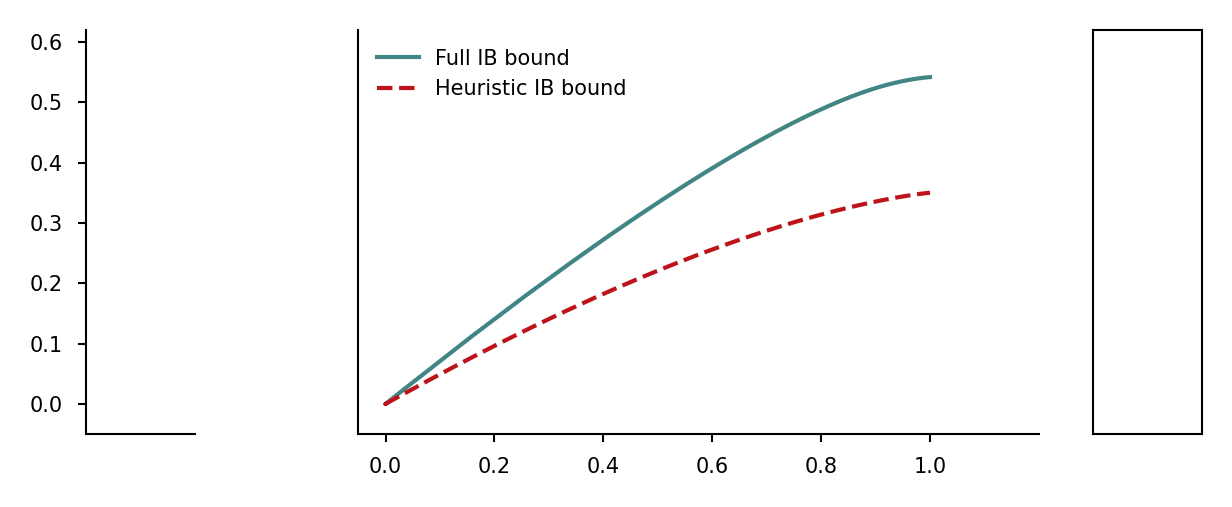

In [ ]:
cmap_r = matplotlib.colormaps.get_cmap('Reds')

legend_handles = []  
legend_labels = []

# make x scale constant across both subplots
# Calculate width ratio based on x-limits
xlim_left = (0.2 - 0)  # width of left subplot
xlim_mid = (1.2 - (-0.05))  # width of right subplot
xlim_right = (0.2 - 0)  # width of right subplot
width_ratio = [xlim_left, xlim_mid, xlim_right]

# fig, axs = plt.subplots(1, 3, figsize=(4.5, 1.75), dpi=300, gridspec_kw={'width_ratios': width_ratio})
fig = plt.figure(figsize=(4.8, 1.75), dpi=300)

# Create GridSpec with 5 columns: [left_plot, gap1, middle_plot, gap2, right_plot]
# The gaps are just empty space columns
gs = gridspec.GridSpec(1, 5, figure=fig, 
                       width_ratios=[xlim_left, 0.3, xlim_mid, 0.1, xlim_right],
                       wspace=0)  # Set wspace to 0 since we're using gap columns

# Create subplots in non-gap columns
axs = [fig.add_subplot(gs[0, 0]),   # left subplot
       fig.add_subplot(gs[0, 2]),   # middle subplot  
       fig.add_subplot(gs[0, 4])]   # right subplot

axs[0].set_xlim(0,0.2)
axs[0].set_ylim(-0.05,0.62)
axs[0].set_xticks([])
format_axis(axs[0])

fullbound, = axs[1].plot(emp_bound['I_XR'],emp_bound['I_RY'],c=cmap_t(.8),linewidth=1,label='Full IB bound')
heurbound, = axs[1].plot(emp_bound_heur['I_XR'],emp_bound_heur['I_RY'],'--',c=cmap_r(.8),linewidth=1,label='Heuristic IB bound')

format_axis(axs[1])
axs[1].legend(fontsize=5, frameon=False)
axs[1].set_xlim(-0.05,1.2)
axs[1].set_xticks(np.arange(0,1.2,0.2))
axs[1].set_ylim(-0.05,0.62)
axs[1].set_yticks([])

axs[2].set_xlim(0,0.2)
axs[2].set_ylim(-0.05,0.62)
axs[2].set_xticks([])
axs[2].spines['left'].set_linewidth(0.5)
axs[2].spines['right'].set_linewidth(0.5)
axs[2].spines['top'].set_linewidth(0.5)
axs[2].spines['bottom'].set_linewidth(0.5)
axs[2].tick_params(axis='x', labelsize=5, width=0.5, length=2)
axs[2].tick_params(axis='y', labelsize=5, width=0.5, length=2)
axs[2].set_yticks([])
axs[2].set_xticks([])

savefig(fig, 'Figure2/figure2_data_schematic_template')

## Figure 3
IB-analyses of human behavior on the bead-prediction experiment

In [ ]:
# compute empirical IB bound for the fully optimal strategy
beads_Xset = utils.get_beads_Xset(wsize)
p_XgY = utils.P_beads_g_jar(beads_Xset,E,H)
emp_bound_opt_beads = utils.get_IB_bound_emp(beads_emp,)

In [6]:
beads_emp

array([0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 0.,
       1., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 1.,
       0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1.,
       0., 0., 0., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1.,
       1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0.,
       0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 1.

### Compute IB measures for each run for each participant
And compute CI of $I(R;Y)$

In [ ]:
# import preprocessed human behavioral data
datadf_beads = pd.read_csv(beads_datadir + "sj-preproc-data.csv")

ibdf_beads = pd.DataFrame({
    'subject_ID': [],
    'subject_index': [],
    'run': [],
    'Ixr': [],
    'Iry': [],
    'Iry_CI_lower': [],
    'Iry_CI_upper': []
})

X, Y = utils.getXY_beads(beads_emp, jars_emp, wsize,encodeX=True)
Xcard = 2**wsize
Rcard = 2
Ycard = 2

sjlist = datadf_beads['subject_index'].unique()
for ii,sj in enumerate(sjlist):
    for run in [1,2]:

        sjdf = pd.DataFrame({
            'subject_ID': [''],
            'subject_index': [np.nan],
            'run': [np.nan],
            'Ixr': [np.nan],
            'Iry': [np.nan],
            'Iry_CI_lower': [np.nan],
            'Iry_CI_upper': [np.nan]
        })

        df_ = datadf_beads[(datadf_beads['subject_index']==sj) & (datadf_beads['run']==run)]
        R = utils.getR_beads(df_['choice'].to_numpy(),wsize)
        Ixr = utils.mutual_inf_nsb(X,R,[Xcard,Rcard])
        Iry = utils.mutual_inf_nsb(R,Y,[Rcard,Ycard])
        Iry_CI = utils.get_Iry_CI(R,Y,CI,boot_iters,Rcard=Rcard,Ycard=Ycard,seed=234)

        sjdf['subject_ID'] = df_['subject_ID'].iloc[0]
        sjdf['subject_index'] = sj
        sjdf['run'] = run
        sjdf['Ixr'] = Ixr
        sjdf['Iry'] = Iry
        sjdf['Iry_CI_lower'] = Iry_CI[0]
        sjdf['Iry_CI_upper'] = Iry_CI[1]

        ibdf_beads = pd.concat((ibdf_beads, sjdf), ignore_index=True)

In [ ]:
# compute information efficiency for each subject and run
ibdf_beads['efficiency'] = ibdf_beads['Iry'] / emp

In [37]:
datadf

,subject_ID,subject_index,run,trial,jar,bead,choice
0,6107f24d21eaa93618cf9191,0.0,1.0,0.0,1.0,0.0,0.0
1,6107f24d21eaa93618cf9191,0.0,1.0,1.0,1.0,1.0,0.0
2,6107f24d21eaa93618cf9191,0.0,1.0,2.0,1.0,1.0,0.0
3,6107f24d21eaa93618cf9191,0.0,1.0,3.0,1.0,1.0,1.0
4,6107f24d21eaa93618cf9191,0.0,1.0,4.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...
69995,663a5538ea4ded3dd872258e,69.0,2.0,495.0,1.0,1.0,1.0
69996,663a5538ea4ded3dd872258e,69.0,2.0,496.0,1.0,1.0,1.0
69997,663a5538ea4ded3dd872258e,69.0,2.0,497.0,1.0,0.0,1.0
69998,663a5538ea4ded3dd872258e,69.0,2.0,498.0,1.0,1.0,1.0
